# **A. Quantum k-Nearest Neighbors (QkNN) usando SWAP Test**

##*Universidad Nacional Autónoma de México*

#Laboratorio Avanzado de Procesamiento de Imágenes

#Autor: **Sebastián González Juárez**

Temas Selectos de Ingenieria III - **Introducción a la computación cuántica**.

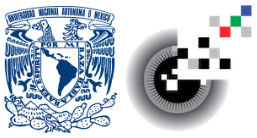

---
<div style="text-align: justify;">

# **1. Introducción**

El **Machine Learning (Aprendizaje Automático)** es un área de la inteligencia artificial que busca desarrollar algoritmos capaces de aprender patrones a partir de datos y realizar predicciones o decisiones sin ser programados explícitamente para cada tarea.

De manera general, los métodos de Machine Learning se pueden clasificar en tres grandes categorías:

- **Aprendizaje supervisado**: el modelo aprende a partir de datos etiquetados. Ejemplo: clasificación y regresión.
- **Aprendizaje no supervisado**: el modelo busca patrones en datos sin etiquetas. Ejemplo: clustering.
- **Aprendizaje por refuerzo**: el modelo aprende mediante interacción con un entorno, optimizando una recompensa.

En este notebook nos enfocaremos en un problema de **clasificación supervisada**, donde el objetivo es asignar una etiqueta a una nueva muestra basándose en datos previamente conocidos.

</div>

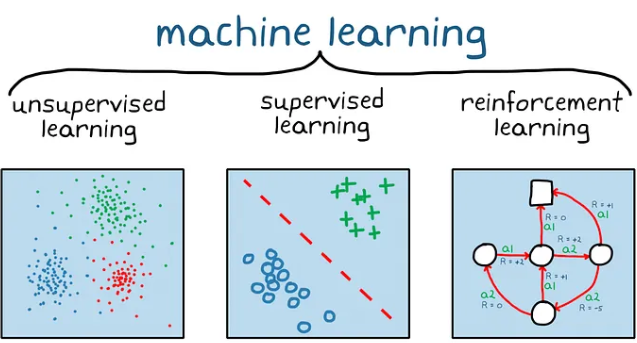

<div style="text-align: justify;">

## k-Nearest Neighbors (kNN)

El algoritmo **k-Nearest Neighbors (kNN)** compara un nuevo dato $x$ con todos los datos de entrenamiento $x_i$ mediante una medida de distancia. La opción más común es la **distancia euclidiana**, definida como $$d(x,x_i)=\sqrt{\sum_j (x_j-x_{i,j})^2}.$$ Esta distancia se calcula para todos los ejemplos del conjunto de entrenamiento y después se ordena de menor a mayor. Para implementar kNN, no es necesario conservar la raíz cuadrada, ya que esta no cambia el orden de las distancias; por ello, en el código usaremos la forma simplificada $$d_i=\sum_j (x_j-x_{i,j})^2.$$ Luego se seleccionan los $k$ valores más pequeños, es decir, los $k$ vecinos más cercanos a $x$, y se observan sus etiquetas. Por ejemplo, si los vecinos tienen clases $[0, 0, 2]$, se asigna la clase $0$ porque aparece más veces. A esta idea se le llama **modo**, es decir, elegir el valor que más se repite en un conjunto. De forma general, la predicción puede escribirse como $$\hat{y}(x)=\mathrm{modo}\big(\{y_i \mid x_i \in N_k(x)\}\big).$$

</div>

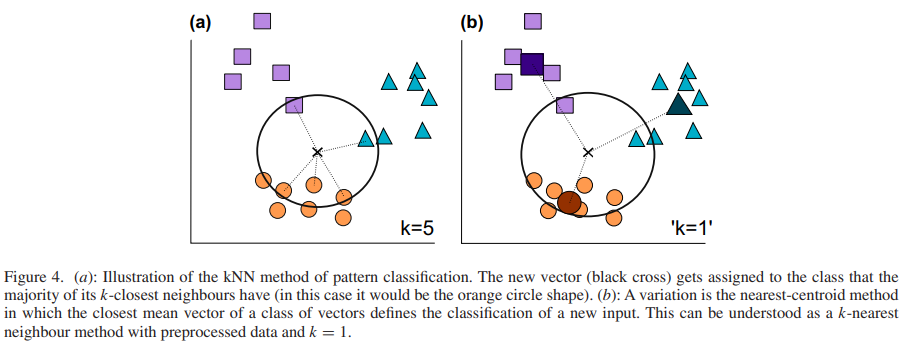

<div style="text-align: justify;">

## Quantum k-Nearest Neighbors (QkNN)

El algoritmo **Quantum k-Nearest Neighbors (QkNN)** sigue la misma idea que kNN clásico: clasificar un nuevo dato comparándolo con los ejemplos de entrenamiento y tomando una decisión basada en sus vecinos más “cercanos”. Sin embargo, la diferencia clave es cómo se mide esta cercanía.

En lugar de utilizar una distancia clásica como la euclidiana, en QkNN los datos se codifican como estados cuánticos $|x\rangle$ y $|x_i\rangle$, y la similitud entre ellos se mide mediante la **fidelidad cuántica**, definida como $$|\langle x \mid x_i \rangle|^2.$$ Esta cantidad toma valores entre 0 y 1, donde valores cercanos a 1 indican que los estados son muy similares, y valores cercanos a 0 indican que son muy diferentes.

</div>

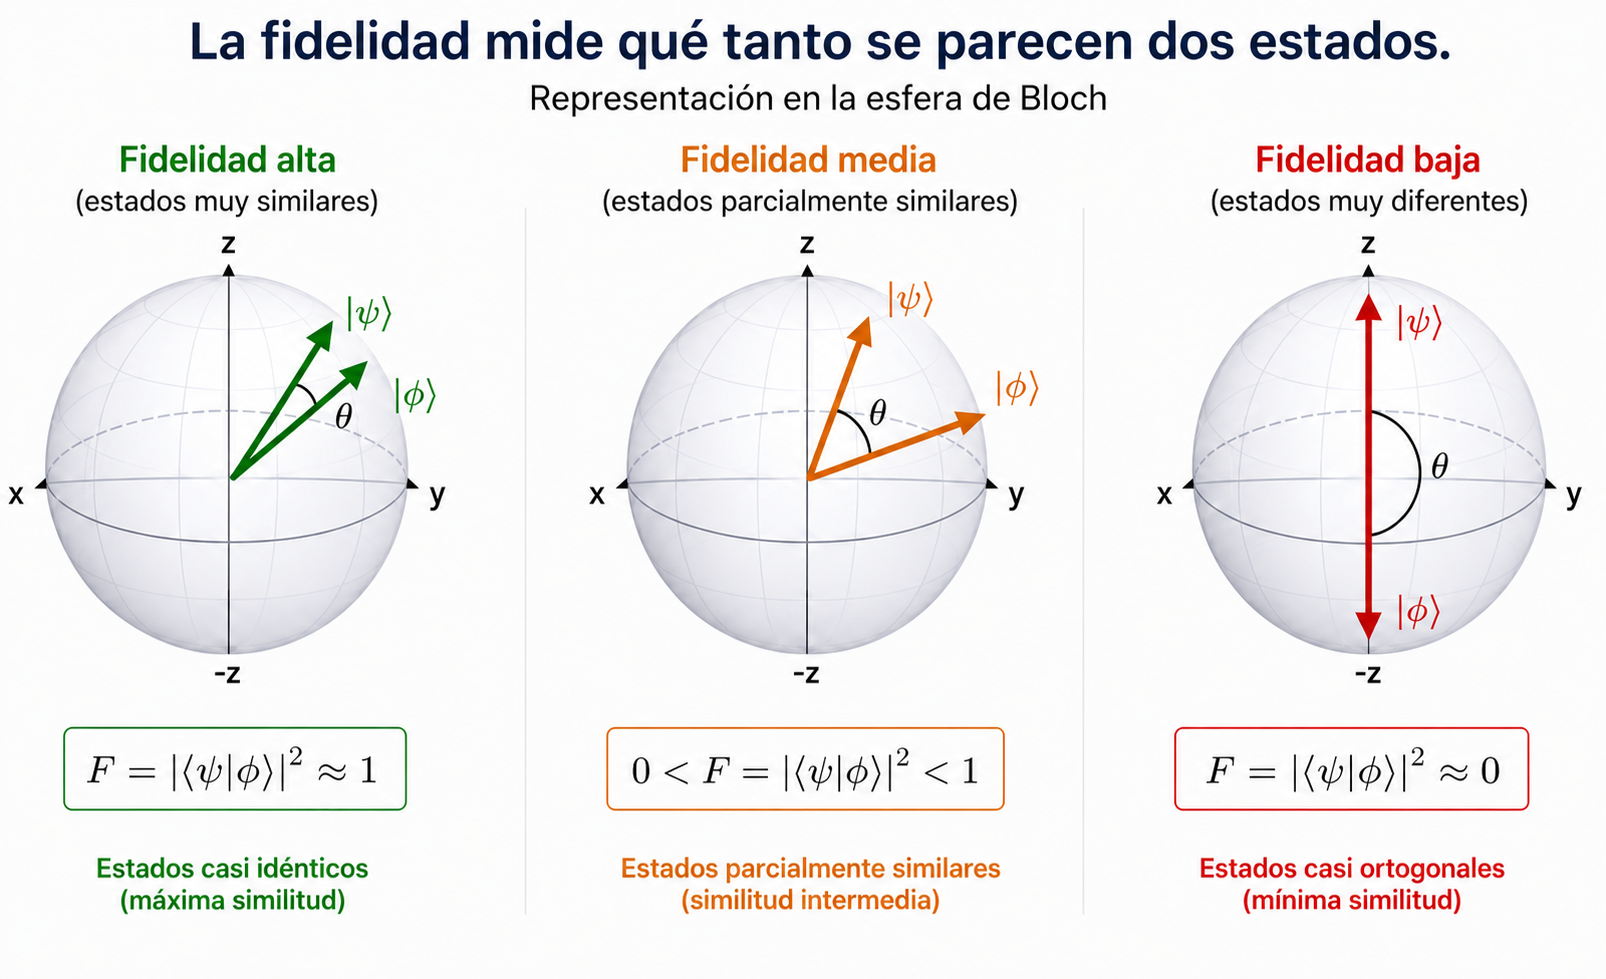

<div style="text-align: justify;">

A diferencia del caso clásico, donde buscamos las distancias más pequeñas, en QkNN buscamos las similitudes más grandes. Es decir, seleccionamos los $k$ datos de entrenamiento con mayor fidelidad respecto al nuevo dato. Posteriormente, al igual que en kNN clásico, se asigna la clase más frecuente entre esos vecinos.

En resumen, QkNN reemplaza el cálculo de distancia por un cálculo de similitud cuántica, manteniendo la misma estructura de decisión basada en vecinos cercanos.

</div>

<div style="text-align: justify;">

## SWAP Test

Para calcular la **fidelidad** entre dos estados cuánticos $|x\rangle$ y $|x_i\rangle$, es decir,

$$
|\langle x \mid x_i \rangle|^2,
$$

utilizamos el **SWAP test**, un circuito cuántico que convierte este traslape en una probabilidad medible.

El circuito emplea un qubit auxiliar (ancilla), dos compuertas de Hadamard y una serie de compuertas **CSWAP** (una por cada qubit), que intercambian los registros $|x\rangle$ y $|x_i\rangle$ condicionadas al estado del ancilla.

</div>

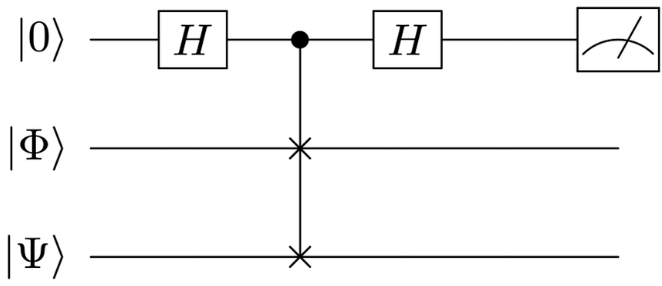

`Estado inicial`  
Sistema sin correlación  

$$|0\rangle|\Phi\rangle|\Psi\rangle$$

`Hadamard al ancilla`

Se crea superposición  

$$\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)|\Phi\rangle|\Psi\rangle$$

`CSWAP`
Controla intercambio según el ancilla  

$$\frac{1}{\sqrt{2}}\big(|0\rangle|\Phi\rangle|\Psi\rangle + |1\rangle|\Psi\rangle|\Phi\rangle\big)$$



`Hadamard final`
Se produce interferencia

$$\frac{1}{2}\Big[|0\rangle(|\Phi\rangle|\Psi\rangle + |\Psi\rangle|\Phi\rangle) + |1\rangle(|\Phi\rangle|\Psi\rangle - |\Psi\rangle|\Phi\rangle)\Big]$$

`Probabilidad de medir 0`
Contiene la similitud entre estados

$$P(0) = \frac{1}{2} + \frac{1}{2}|\langle \Phi | \Psi \rangle|^2$$


<div style="text-align: justify;">

O en otras palabras: Después de ejecutar el circuito, se mide el qubit ancilla. La probabilidad de obtener el resultado $|0\rangle$ está directamente relacionada con la similitud entre los estados:

$$
P(0) = \frac{1}{2} + \frac{1}{2}|\langle x \mid x_i \rangle|^2
$$

De esta expresión se recupera la fidelidad como:

$$
|\langle x \mid x_i \rangle|^2 = 2P(0) - 1
$$

En la práctica, cada comparación entre un dato de entrada $x$ y un ejemplo $x_i$ se realiza ejecutando este circuito y estimando $P(0)$, utilizando este valor como medida de similitud para seleccionar los $k$ vecinos más cercanos.

</div>

---

# **2. Instalación e importaciones**

<div style="text-align: justify;">

En esta versión implementaremos un **Quantum k-Nearest Neighbors (QkNN)** usando **SWAP test** para clasificar el conjunto **Iris completo**, considerando sus tres clases: *setosa*, *versicolor* y *virginica*. Para ello, utilizaremos **Qiskit** para construir y simular los circuitos cuánticos, **Scikit-learn** para cargar el dataset, normalizar los datos, dividir el conjunto y evaluar el desempeño, y **Matplotlib/Seaborn** para visualizar los datos y los resultados.

</div>

In [ ]:
!pip install qiskit qiskit-aer scikit-learn matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.9 MB/s eta 0:00:00


In [ ]:
!pip install pylatexenc -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display
from collections import Counter

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import circuit_drawer

<div style="text-align: justify;">

A continuación se definen algunos parámetros del experimento, incluyendo la **semilla** para reproducibilidad, el número de **mediciones** del circuito cuántico, el número de **vecinos** considerados en QkNN y el **simulador** cuántico que se utilizará.

</div>

In [ ]:
SEED = 42
np.random.seed(SEED)

SHOTS = 1000
K = 3

simulator = AerSimulator()

---
<div style="text-align: justify;">

## 3. Carga del dataset Iris

Para evaluar el algoritmo QkNN utilizamos el conjunto de datos **Iris**, un problema clásico de clasificación multiclase que contiene tres categorías:

- *setosa*
- *versicolor*
- *virginica*.

Cada muestra está descrita por cuatro características:
- longitud y ancho del sépalo
- longitud y ancho del pétalo.

</div>

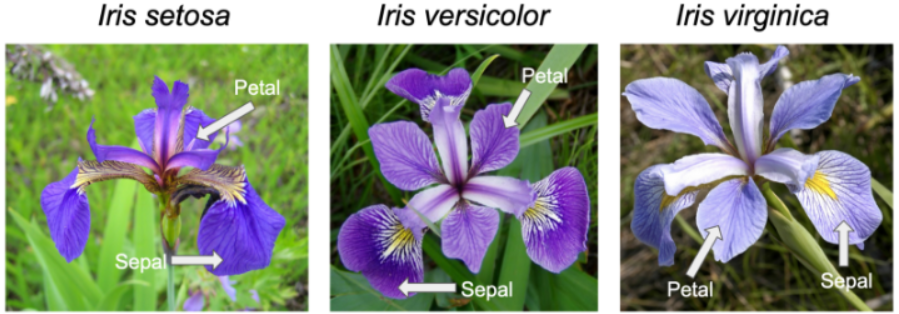

El dataset contiene 150 muestras, cada una con 4 características:

In [ ]:
# Cargar dataset Iris
iris = load_iris()

X = iris.data        # características
y = iris.target      # etiquetas (0, 1, 2)
labels = iris.target_names

print("Clases:", labels)
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Clases: ['setosa' 'versicolor' 'virginica']
Forma de X: (150, 4)
Forma de y: (150,)


<div style="text-align: justify;">

El pairplot permite analizar las relaciones entre todas las variables del dataset, mientras que PCA ofrece una proyección compacta para visualizar la estructura global.

</div>

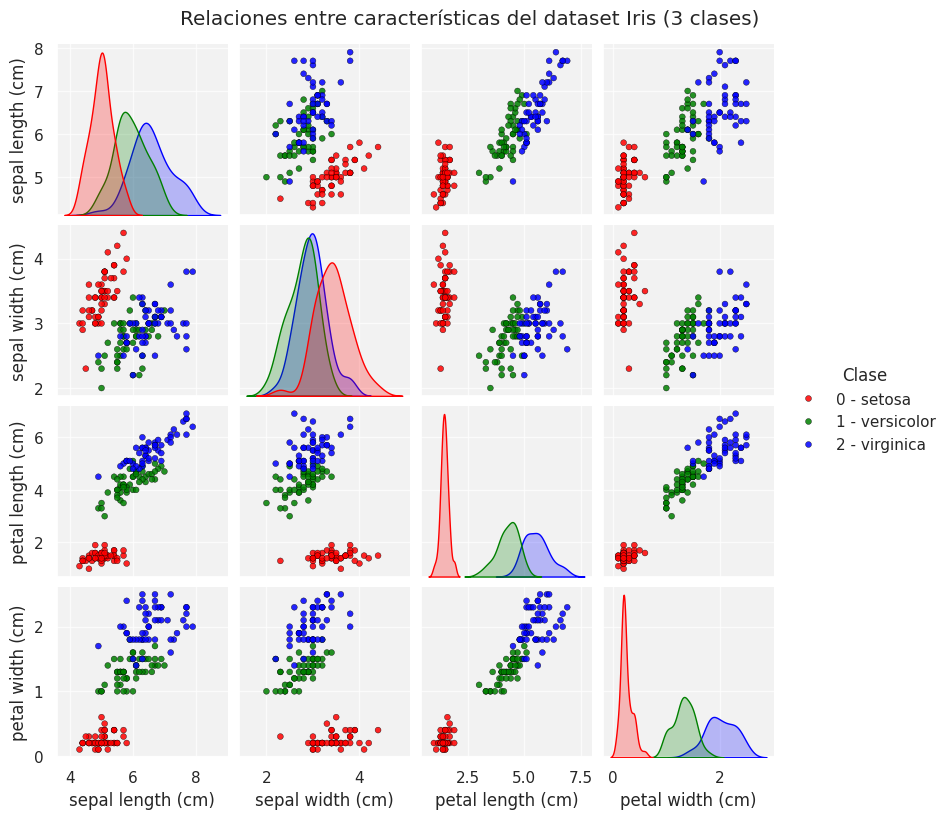

In [ ]:
# DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df["Clase"] = [f"{i} - {labels[i]}" for i in y]

# Estilo
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#f2f2f2",
    "grid.color": "white",
    "grid.linestyle": "-",
    "grid.alpha": 0.7
})

# Palette consistente
palette = {
    "0 - setosa": "red",
    "1 - versicolor": "green",
    "2 - virginica": "blue"
}

# Pairplot
g = sns.pairplot(
    df,
    hue="Clase",
    palette=palette,
    diag_kind="kde",
    plot_kws={
        "s": 18,
        "edgecolor": "black",
        "linewidth": 0.3,
        "alpha": 0.85
    },
    height=2
)

plt.suptitle("Relaciones entre características del dataset Iris (3 clases)", y=1.02)
plt.show()

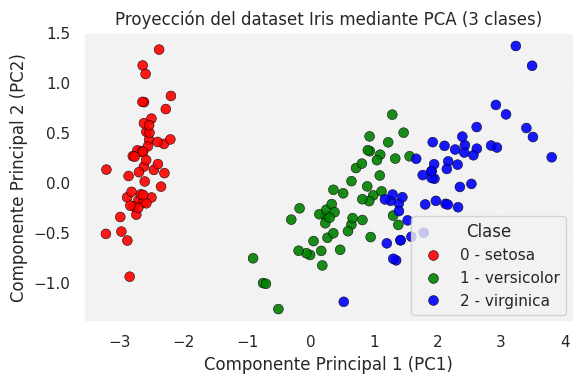

In [ ]:
X_pca = PCA(n_components=2).fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["Clase"] = [f"{i} - {labels[i]}" for i in y]

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Clase",
    palette={
        "0 - setosa": "red",
        "1 - versicolor": "green",
        "2 - virginica": "blue"
    },
    s=50,
    edgecolor="black",
    linewidth=0.4,
    alpha=0.9
)

plt.xlabel("Componente Principal 1 (PC1)")
plt.ylabel("Componente Principal 2 (PC2)")
plt.title("Proyección del dataset Iris mediante PCA (3 clases)")
plt.legend(title="Clase")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="text-align: justify;">

### Preparación del conjunto de datos

Antes de aplicar el algoritmo QkNN, es necesario preparar los datos. En particular, se realiza una **normalización** de las características para que todas se encuentren en el mismo rango.


Posteriormente, el conjunto se divide en datos de entrenamiento y prueba para evaluar el desempeño del modelo.

</div>

In [ ]:
# Normalización: xi​→[0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=SEED, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (105, 4)
Test: (45, 4)


---

<div style="text-align: justify;">

# 4. Codificación cuántica de los datos

Para aplicar el SWAP Test, primero debemos transformar cada muestra clásica en un estado cuántico.

Esta etapa se conoce como **codificación de datos** (*data encoding*) y no es única. En este notebook usaremos la siguiente codificación por característica:

$$
x \rightarrow \left[\sqrt{x}, \sqrt{1-x}\right]
$$

Esta transformación es útil porque convierte cada valor escalar en un vector de dos componentes normalizado:

$$
|\psi(x)\rangle = \sqrt{x}|0\rangle + \sqrt{1-x}|1\rangle
$$

En efecto, su norma cumple:

$$
|\sqrt{x}|^2 + |\sqrt{1-x}|^2 = x + (1-x) = 1
$$

Por lo tanto, cada característica puede interpretarse como el estado de un qubit.

</div>


<div style="text-align: justify;">

Para un vector:

$$
x = (x_1, ..., x_n)
$$

el estado cuántico se construye como:

$$
|x\rangle = \bigotimes_{i=1}^{n} |\psi(x_i)\rangle
$$

Por ejemplo, con **4 características se usan 4 qubits** y el estado tiene dimensión:

$$
2^4 = 16
$$

Esta codificación es independiente del número de clases; la diferencia entre clasificación binaria y multiclase aparece únicamente en la etapa de votación del k-NN.

</div>

In [ ]:
def encode_feature(x):
    """
    Codifica un escalar en un estado de 1 qubit:
    x -> [sqrt(x), sqrt(1-x)]
    """
    x = np.clip(x, 0.0, 1.0)
    return np.array([np.sqrt(x), np.sqrt(1 - x)], dtype=float)


def encode_vector(x):
    """
    Codifica un vector completo usando producto tensorial.
    """
    x = np.clip(x, 0.0, 1.0)

    state = encode_feature(x[0])

    for i in range(1, len(x)):
        state = np.kron(state, encode_feature(x[i]))

    # Normalización final (por seguridad numérica)
    state = state / np.linalg.norm(state)

    return state

In [ ]:
# Ejemplo con una muestra del dataset
x_example = X_scaled[0]

print("Vector clásico original:")
print(x_example)

print("\nCodificación de cada característica:")
states = []

for i, value in enumerate(x_example):
    encoded = encode_feature(value)
    states.append(encoded)

    print(f"x_{i+1} = {value:.4f}")
    print(f"|ψ(x_{i+1})> = {encoded}")
    print(f"Norma: {np.linalg.norm(encoded):.4f}")
    print("-" * 40)

# Construcción usando la función
state = encode_vector(x_example)

print("\nEstado final usando encode_vector:")
print(state)

print("\nVerificación final:")
print("Dimensión:", len(state))
print("Qubits:", int(np.log2(len(state))))
print("Norma:", np.linalg.norm(state))

Vector clásico original:
[0.22222222 0.625      0.06779661 0.04166667]

Codificación de cada característica:
x_1 = 0.2222
|ψ(x_1)> = [0.47140452 0.8819171 ]
Norma: 1.0000
----------------------------------------
x_2 = 0.6250
|ψ(x_2)> = [0.79056942 0.61237244]
Norma: 1.0000
----------------------------------------
x_3 = 0.0678
|ψ(x_3)> = [0.26037782 0.9655068 ]
Norma: 1.0000
----------------------------------------
x_4 = 0.0417
|ψ(x_4)> = [0.20412415 0.97894501]
Norma: 1.0000
----------------------------------------

Estado final usando encode_vector:
[0.01980761 0.09499397 0.07344859 0.35224707 0.01534291 0.07358201
 0.05689303 0.27284941 0.03705665 0.17771745 0.13740973 0.65899392
 0.02870396 0.13765934 0.10643712 0.5104545 ]

Verificación final:
Dimensión: 16
Qubits: 4
Norma: 1.0


<div style="text-align: justify;">

El producto tensorial genera todas las combinaciones posibles entre las amplitudes de cada característica.

Si cada característica se codifica como:

$$
|\psi(x_i)\rangle = [a_i, b_i]
$$

entonces para 4 características:

$$
|x\rangle = [a_1, b_1] \otimes [a_2, b_2] \otimes [a_3, b_3] \otimes [a_4, b_4]
$$

expande a:

$$
\begin{aligned}
|x\rangle = [&
a_1a_2a_3a_4,\;
a_1a_2a_3b_4,\;
a_1a_2b_3a_4,\;
a_1a_2b_3b_4, \\
&
a_1b_2a_3a_4,\;
a_1b_2a_3b_4,\;
a_1b_2b_3a_4,\;
a_1b_2b_3b_4, \\
&
b_1a_2a_3a_4,\;
b_1a_2a_3b_4,\;
b_1a_2b_3a_4,\;
b_1a_2b_3b_4, \\
&
b_1b_2a_3a_4,\;
b_1b_2a_3b_4,\;
b_1b_2b_3a_4,\;
b_1b_2b_3b_4
]
\end{aligned}
$$

Así se obtienen las 16 amplitudes del estado final.

</div>


---

<div style="text-align: justify;">

# 5. SWAP Test

Recordemos que el circuito utiliza:

- 1 qubit auxiliar (ancilla)
- Los qubits que representan $|\psi\rangle$
- Los qubits que representan $|\phi\rangle$

El procedimiento es:

1. Inicializar el ancilla en $|0\rangle$
2. Aplicar una compuerta Hadamard
3. Aplicar compuertas SWAP controladas (CSWAP)
4. Aplicar otra Hadamard al ancilla
5. Medir el ancilla

La probabilidad de medir $|0\rangle$ es:

$$
P(0) = \frac{1 + |\langle \psi | \phi \rangle|^2}{2}
$$

De aquí podemos obtener la similitud:

$$
|\langle \psi | \phi \rangle|^2 = 2P(0) - 1
$$

Esto permite estimar qué tan similares son dos vectores, lo cual es clave en el algoritmo k-NN.

</div>

In [ ]:
def dibujar_swap_test(n):
    # Crea un circuito con 1 ancilla + n qubits para |x> + n qubits para |x_i>
    qc = QuantumCircuit(1 + 2*n)

    # Aplica Hadamard inicial al ancilla
    qc.h(0)

    # Aplica una compuerta CSWAP por cada par de qubits de los registros
    for i in range(n):
        qc.cswap(0, 1+i, 1+n+i)

    # Aplica Hadamard final al ancilla
    qc.h(0)

    # Muestra el circuito en formato gráfico de Qiskit
    display(qc.draw("text"))

    # Devuelve el circuito por si se quiere reutilizar
    return qc

In [ ]:
# Para Iris usamos 4 características, por lo tanto 4 qubits por registro
dibujar_swap_test(n=4)

┌───┐            ┌───┐
q_0: ┤ H ├─■──■──■──■─┤ H ├
     └───┘ │  │  │  │ └───┘
q_1: ──────X──┼──┼──┼──────
           │  │  │  │      
q_2: ──────┼──X──┼──┼──────
           │  │  │  │      
q_3: ──────┼──┼──X──┼──────
           │  │  │  │      
q_4: ──────┼──┼──┼──X──────
           │  │  │  │      
q_5: ──────X──┼──┼──┼──────
              │  │  │      
q_6: ─────────X──┼──┼──────
                 │  │      
q_7: ────────────X──┼──────
                    │      
q_8: ───────────────X──────

In [ ]:
def swap_test(state1, state2):
    # Calcula cuántos qubits necesita cada estado
    n = int(np.log2(len(state1)))

    # Crea el circuito con: 1 qubit ancilla + n qubits para state1 + n qubits para state2 y 1 bit clásico para medir únicamente el ancilla
    qc = QuantumCircuit(1 + 2*n, 1)

    # Inicializa el primer registro con el estado state1
    qc.initialize(state1, range(1, n+1))

    # Inicializa el segundo registro con el estado state2
    qc.initialize(state2, range(n+1, 2*n+1))

    # Aplica Hadamard inicial al ancilla
    qc.h(0)

    # Aplica CSWAP entre cada par de qubits de los dos registros
    for i in range(n):
        qc.cswap(0, 1+i, 1+n+i)

    # Aplica Hadamard final al ancilla
    qc.h(0)

    # Mide el ancilla y guarda el resultado en el bit clásico 0
    qc.measure(0, 0)

    # Transpila el circuito para el simulador elegido
    tqc = transpile(qc, simulator)

    # Ejecuta el circuito usando el número de shots definido arriba
    result = simulator.run(
        tqc,
        shots=SHOTS,
        seed_simulator=SEED
    ).result()

    # Obtiene los conteos de medición del ancilla
    counts = result.get_counts()

    # Estima P(0): frecuencia de medir el ancilla en 0
    p0 = counts.get("0", 0) / SHOTS

    # Recupera la fidelidad usando |<x|xi>|^2 = 2P(0) - 1
    fidelity = 2*p0 - 1

    # Devuelve la fidelidad estimada
    return fidelity

In [ ]:
# Ejemplo de comparación entre dos muestras
x1 = X_scaled[0]
x2 = X_scaled[1]

state1 = encode_vector(x1)
state2 = encode_vector(x2)

sim = swap_test(state1, state2)

print("Similitud:", sim)

Similitud: 0.9359999999999999


---

<div style="text-align: justify;">

# **6. Clasificación con Quantum k-Nearest Neighbors (QkNN)**

Una vez que podemos medir la fidelidad entre dos estados cuánticos mediante el SWAP Test, podemos usar esa cantidad como medida de similitud para clasificar nuevos datos.

El procedimiento es:

1. Tomar un dato de prueba.
2. Codificarlo como estado cuántico.
3. Compararlo con todos los datos de entrenamiento usando el SWAP Test.
4. Ordenar los ejemplos de entrenamiento por mayor fidelidad.
5. Seleccionar los $k$ vecinos más similares.
6. Asignar la clase mediante voto mayoritario.

Este proceso es análogo al k-NN clásico, pero usando una medida de similitud obtenida mediante un circuito cuántico.

</div>

In [ ]:
def classify_qknn(x_test, X_train, y_train, k=3):
    # Guarda pares de la forma (fidelidad, etiqueta)
    similarities = []

    # Codifica el dato de prueba como estado cuántico
    state_test = encode_vector(x_test)

    # Recorre todos los ejemplos de entrenamiento
    for i, x_train in enumerate(X_train):

        # Codifica el ejemplo de entrenamiento como estado cuántico
        state_train = encode_vector(x_train)

        # Calcula la fidelidad entre el dato de prueba y el dato de entrenamiento
        similarity = swap_test(state_test, state_train)

        # Guarda la similitud junto con la clase real del dato de entrenamiento
        similarities.append((similarity, y_train[i]))

    # Ordena los ejemplos por mayor similitud
    similarities.sort(reverse=True, key=lambda x: x[0])

    # Selecciona los k vecinos más similares
    k_nearest = similarities[:k]

    # Extrae las etiquetas de esos k vecinos
    labels = [label for _, label in k_nearest]

    # Realiza voto mayoritario
    prediction = Counter(labels).most_common(1)[0][0]

    # Devuelve la clase predicha
    return prediction

In [ ]:
# Lista para guardar las predicciones del modelo
y_pred = []

# Número total de muestras de prueba
total = len(X_test)

# Clasifica cada muestra del conjunto de prueba
for i, x in enumerate(X_test):
    # Muestra el avance
    print(f"Procesando {i+1}/{total}")

    # Predice la clase usando QkNN
    pred = classify_qknn(x, X_train, y_train, k=K)

    # Guarda la predicción
    y_pred.append(pred)

# Convierte las predicciones a arreglo de NumPy
y_pred = np.array(y_pred)

Procesando 1/45
Procesando 2/45
Procesando 3/45
Procesando 4/45
Procesando 5/45
Procesando 6/45
Procesando 7/45
Procesando 8/45
Procesando 9/45
Procesando 10/45
Procesando 11/45
Procesando 12/45
Procesando 13/45
Procesando 14/45
Procesando 15/45
Procesando 16/45
Procesando 17/45
Procesando 18/45
Procesando 19/45
Procesando 20/45
Procesando 21/45
Procesando 22/45
Procesando 23/45
Procesando 24/45
Procesando 25/45
Procesando 26/45
Procesando 27/45
Procesando 28/45
Procesando 29/45
Procesando 30/45
Procesando 31/45
Procesando 32/45
Procesando 33/45
Procesando 34/45
Procesando 35/45
Procesando 36/45
Procesando 37/45
Procesando 38/45
Procesando 39/45
Procesando 40/45
Procesando 41/45
Procesando 42/45
Procesando 43/45
Procesando 44/45
Procesando 45/45


In [ ]:
# Resultados
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:")
print(accuracy)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy:
0.9333333333333333

Matriz de confusión:
[[15  0  0]
 [ 0 15  0]
 [ 0  3 12]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.83      1.00      0.91        15
           2       1.00      0.80      0.89        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



In [ ]:
print("Comparación real vs predicho:")

for i in range(len(y_test)):
    print(f"Muestra {i+1}: real = {y_test[i]}, predicho = {y_pred[i]}")

Comparación real vs predicho:
Muestra 1: real = 2, predicho = 2
Muestra 2: real = 1, predicho = 1
Muestra 3: real = 2, predicho = 1
Muestra 4: real = 1, predicho = 1
Muestra 5: real = 2, predicho = 2
Muestra 6: real = 2, predicho = 2
Muestra 7: real = 1, predicho = 1
Muestra 8: real = 1, predicho = 1
Muestra 9: real = 0, predicho = 0
Muestra 10: real = 2, predicho = 2
Muestra 11: real = 0, predicho = 0
Muestra 12: real = 0, predicho = 0
Muestra 13: real = 2, predicho = 2
Muestra 14: real = 2, predicho = 2
Muestra 15: real = 0, predicho = 0
Muestra 16: real = 2, predicho = 2
Muestra 17: real = 1, predicho = 1
Muestra 18: real = 0, predicho = 0
Muestra 19: real = 0, predicho = 0
Muestra 20: real = 0, predicho = 0
Muestra 21: real = 1, predicho = 1
Muestra 22: real = 0, predicho = 0
Muestra 23: real = 1, predicho = 1
Muestra 24: real = 2, predicho = 2
Muestra 25: real = 2, predicho = 2
Muestra 26: real = 1, predicho = 1
Muestra 27: real = 1, predicho = 1
Muestra 28: real = 1, predicho = 1

En este experimento se compara un k-NN clásico con su versión cuántica basada en el SWAP Test.

Aunque ambos algoritmos siguen la misma lógica de vecinos más cercanos, la diferencia radica en la métrica utilizada:

- k-NN clásico: distancia en espacio euclidiano
- QkNN: fidelidad entre estados cuánticos

En simulación, el modelo cuántico suele ser más costoso computacionalmente y no necesariamente mejora el desempeño, pero ilustra cómo se pueden incorporar herramientas cuánticas en algoritmos de aprendizaje automático.

In [ ]:
# Crea el modelo clásico con el mismo K
knn = KNeighborsClassifier(n_neighbors=K)

# Entrena el modelo con los datos clásicos
knn.fit(X_train, y_train)

# Realiza predicciones sobre el conjunto de prueba
y_pred_classical = knn.predict(X_test)

# Calcula accuracy clásico
acc_classical = accuracy_score(y_test, y_pred_classical)

print("Accuracy clásico:", acc_classical)
print("Accuracy cuántico:", accuracy)

Accuracy clásico: 0.9333333333333333
Accuracy cuántico: 0.9333333333333333


---
# Proyectos similares:

* Qunatum nearest-centroid method
* Quantum computing for support vector machines
* Quantum algorithms for clustering
* Quantum decision tree
* Quantum state classification with Bayesian methods
* Hidden quantum Markov models
* Quantum principal component analysis

---
**Referencias:**
* https://github.com/nagarx/Quantum-KNN-Classifier-using-Qiskit/blob/main/q-KNN.ipynb
* https://arxiv.org/abs/1409.3097
* https://medium.com/@anabelenmanjavacas/supervised-unsupervised-and-reinforcement-learning-d0a19d016573
* https://www.researchgate.net/figure/SWAP-test-circuit-diagram-for-computing-the-overlap-between-two-quantum-states-and_fig1_360388936